# Forecast for Malaysia Residential Property Data (Johor)

In [22]:
import pandas as pd # for data manipulation and analysis
import numpy as np
import missingno as msno # uncovering missing data patterns in datasets
import matplotlib.pyplot as plt # for plotting graph
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [23]:
df = pd.read_csv('Malaysia Residential Property Data.csv', sep='\t', encoding='utf-8')

In [24]:
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,March 2024,Freehold,374.00,sq.m,106,sq.m,,"RM470,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,May 2023,Leasehold,234.00,sq.m,67,sq.m,,"RM483,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM359,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM435,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,297.00,sq.m,118,sq.m,,"RM373,000.00",NaN


In [25]:

df.dtypes

Property Type                          str
District                               str
Mukim                                  str
Scheme Name/Area                       str
Road Name                              str
Month, Year of Transaction Date        str
Tenure                                 str
Land/Parcel Area                       str
Unit                                   str
Main Floor Area                        str
Unit                                   str
Unit Level                             str
Transaction Price                      str
Unnamed: 13                        float64
dtype: object

In [26]:
df.shape

(410959, 14)

<Axes: >

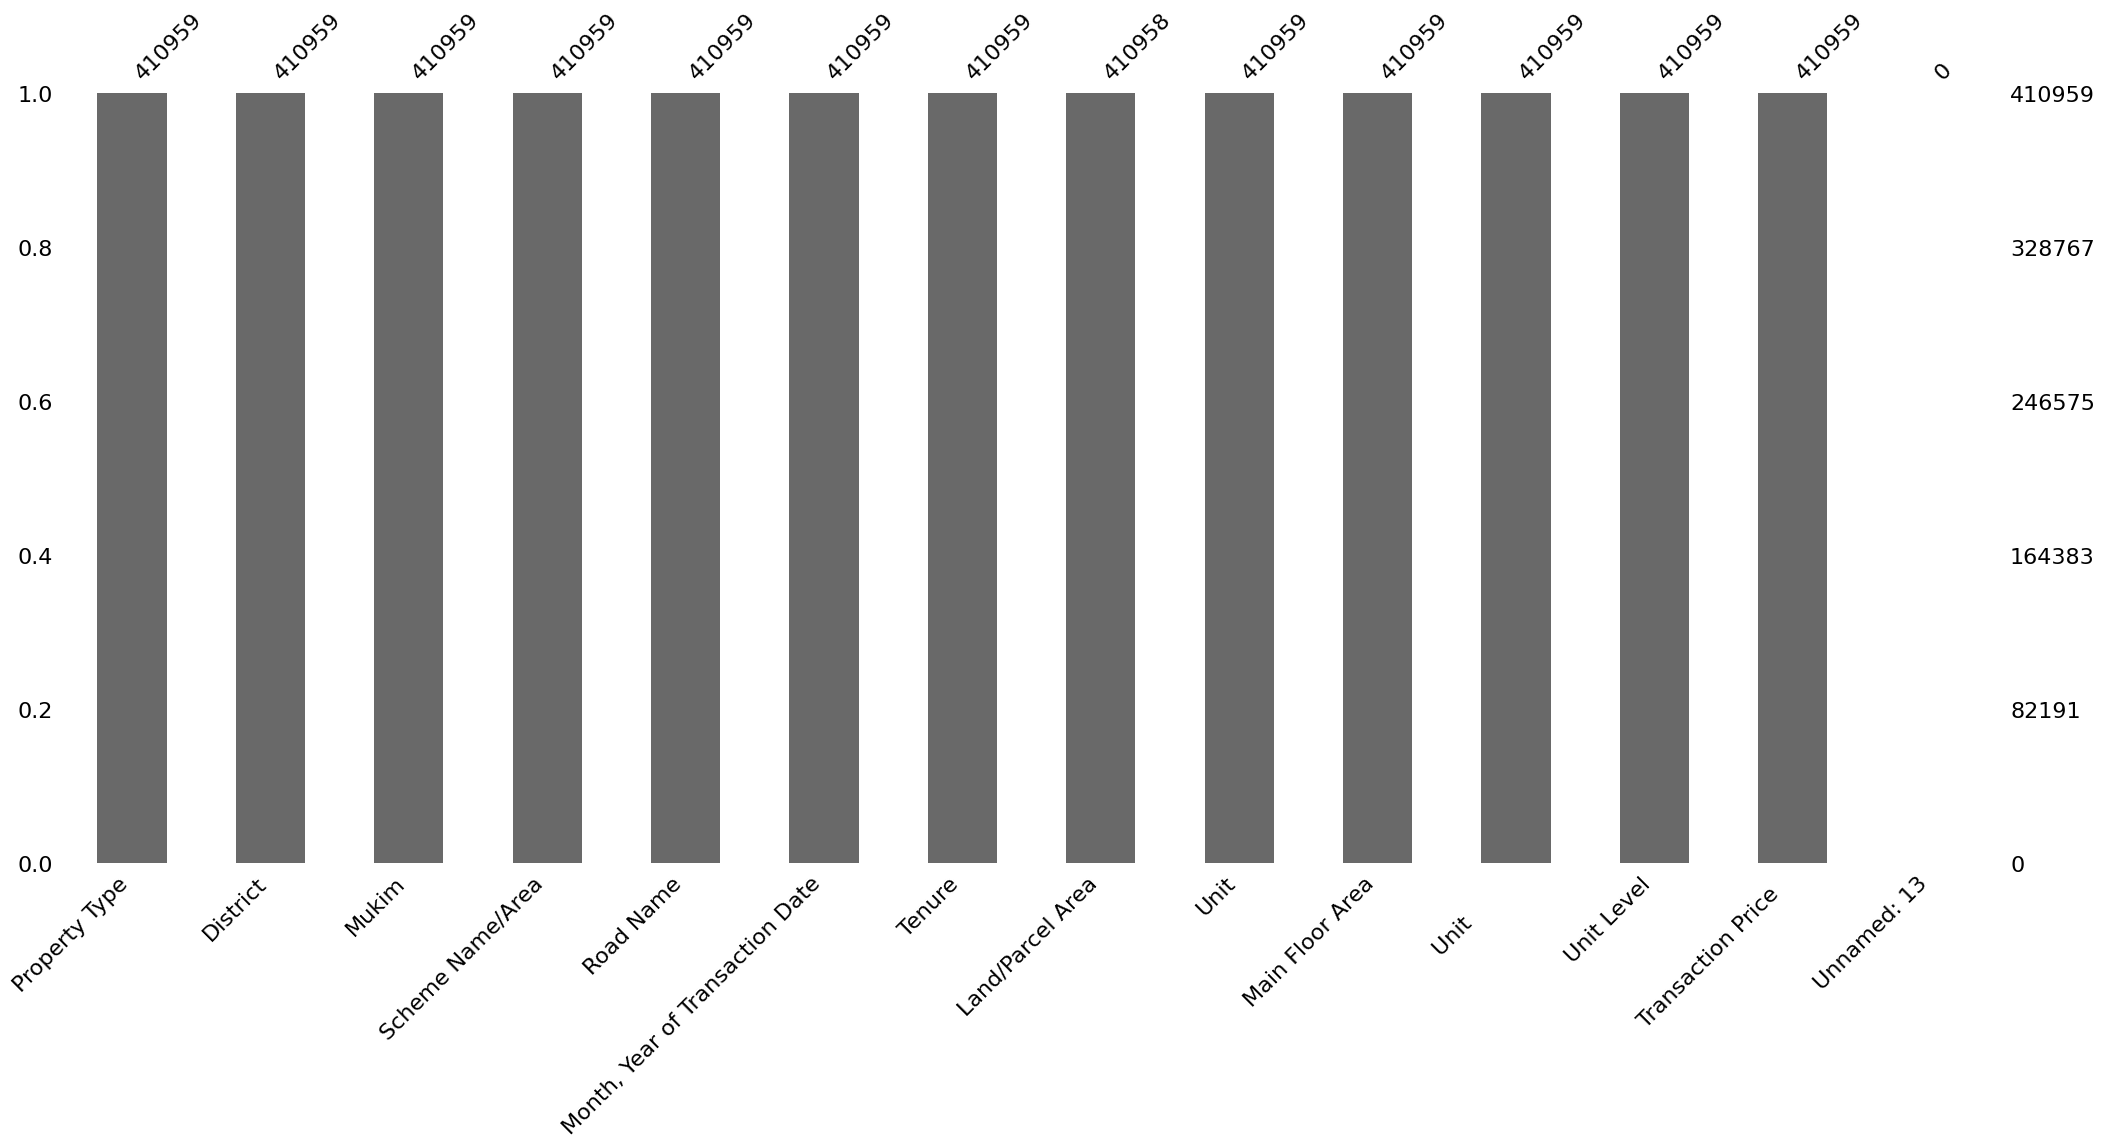

In [27]:
msno.bar(df) 

In [28]:
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column name, view any whitespace


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [29]:

df.duplicated().sum() # total count of duplicate rows present in the DataFrame:

np.int64(447)

In [30]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  1
Unit  :  0
Main Floor Area  :  0
Unit          :  0
Unit Level  :  0
Transaction Price    :  0
Unnamed: 13  :  410959


**Data wrangling**

In [31]:

df.columns = df.columns.str.strip() # remove leading/trailing spaces in column names and print the output after column stripped
print("\nColumn after stripped :\n" + f"{df.columns.tolist()}\n")


Column after stripped :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']



In [32]:
df = df.dropna(axis=1, how='all') # remove the entire column only if all values are NaN and print the output after removed NaN column:
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")


Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']


In [33]:
# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

print(df['Land/Parcel Area'].unique())
print(df['Land/Parcel Area'][df['Land/Parcel Area'] == ''])  # find empty strings

# Clean and convert 'Land/Parcel Area' to numeric
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace(',', '', regex=False).astype(float)

print(df['Main Floor Area'].unique())
print(df['Main Floor Area'][df['Main Floor Area'] == ''])  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

<StringArray>
['374.00', '234.00', '268.00', '297.00', '331.00', '387.00', '478.00',
 '490.00', '433.00', '290.00',
 ...
 '150.31',  '97.63',  '96.52',  '96.53',  '99.86',  '81.70',  '90.81',
 '132.28',  '70.29', '359.63']
Length: 17613, dtype: str
Series([], Name: Land/Parcel Area, dtype: str)
<StringArray>
[  '106',    '67',   '118',   '116',   '217',   '143',    '82',   '133',
   '117',    '93',
 ...
   '630', '1,360',   '661', '2,178', '1,755',   '707',   '610',   '561',
 '1,823',    '23']
Length: 825, dtype: str
Series([], Name: Main Floor Area, dtype: str)


In [34]:
# Convert 'Month, Year of Transaction Date' to datetime
df['Transaction Date'] = pd.to_datetime(df['Month, Year of Transaction Date'], format='%B %Y')

**Analayze data after data wrangling**

In [35]:

df.dtypes

Property Type                                 str
District                                      str
Mukim                                         str
Scheme Name/Area                              str
Road Name                                     str
Month, Year of Transaction Date               str
Tenure                                        str
Land/Parcel Area                          float64
Unit                                          str
Main Floor Area                           float64
Unit                                          str
Unit Level                                    str
Transaction Price                         float64
Transaction Date                   datetime64[us]
dtype: object

<Axes: >

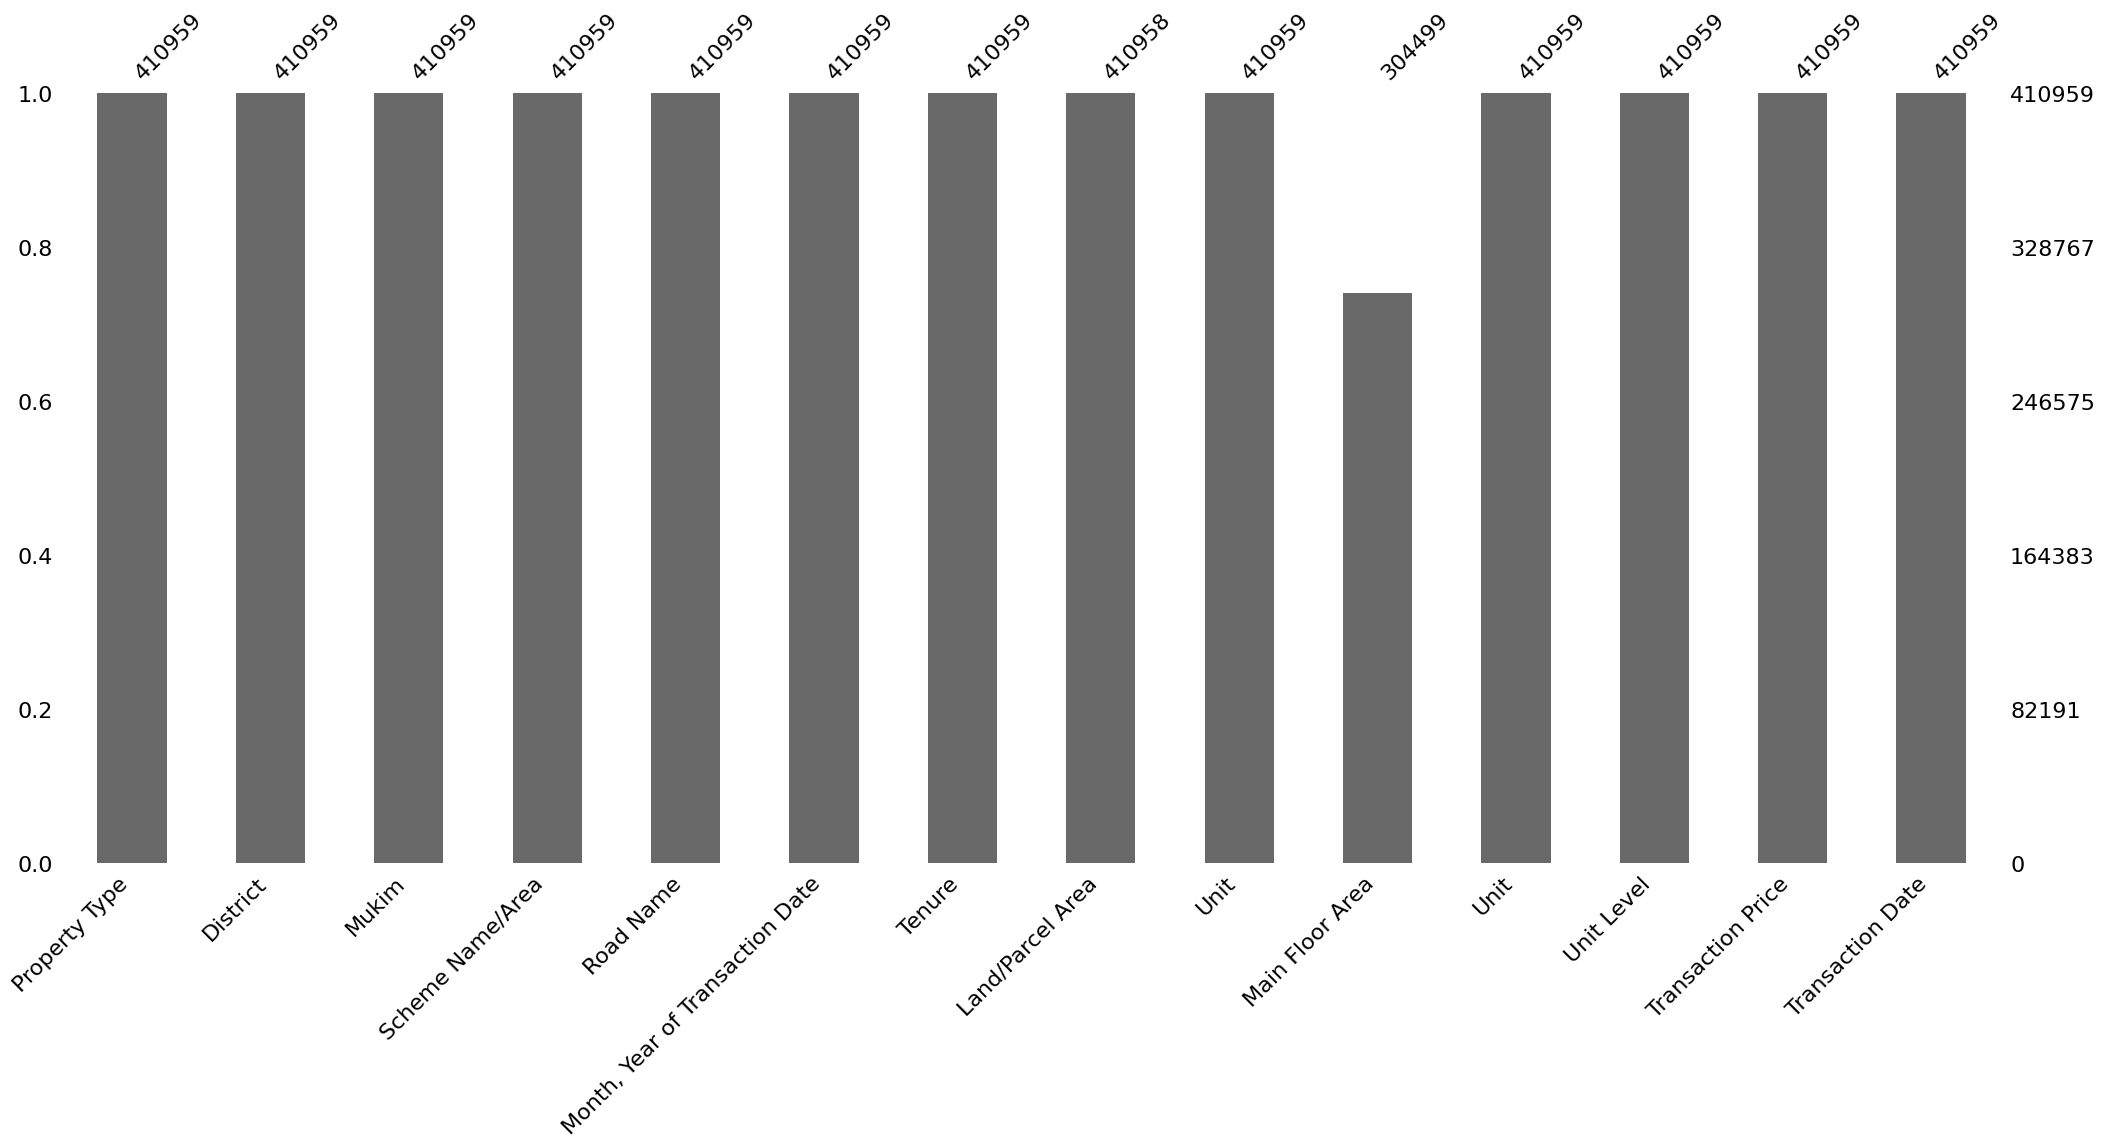

In [36]:
msno.bar(df) # visualizing missing numeric data with bar chart (missingno library)

<Axes: >

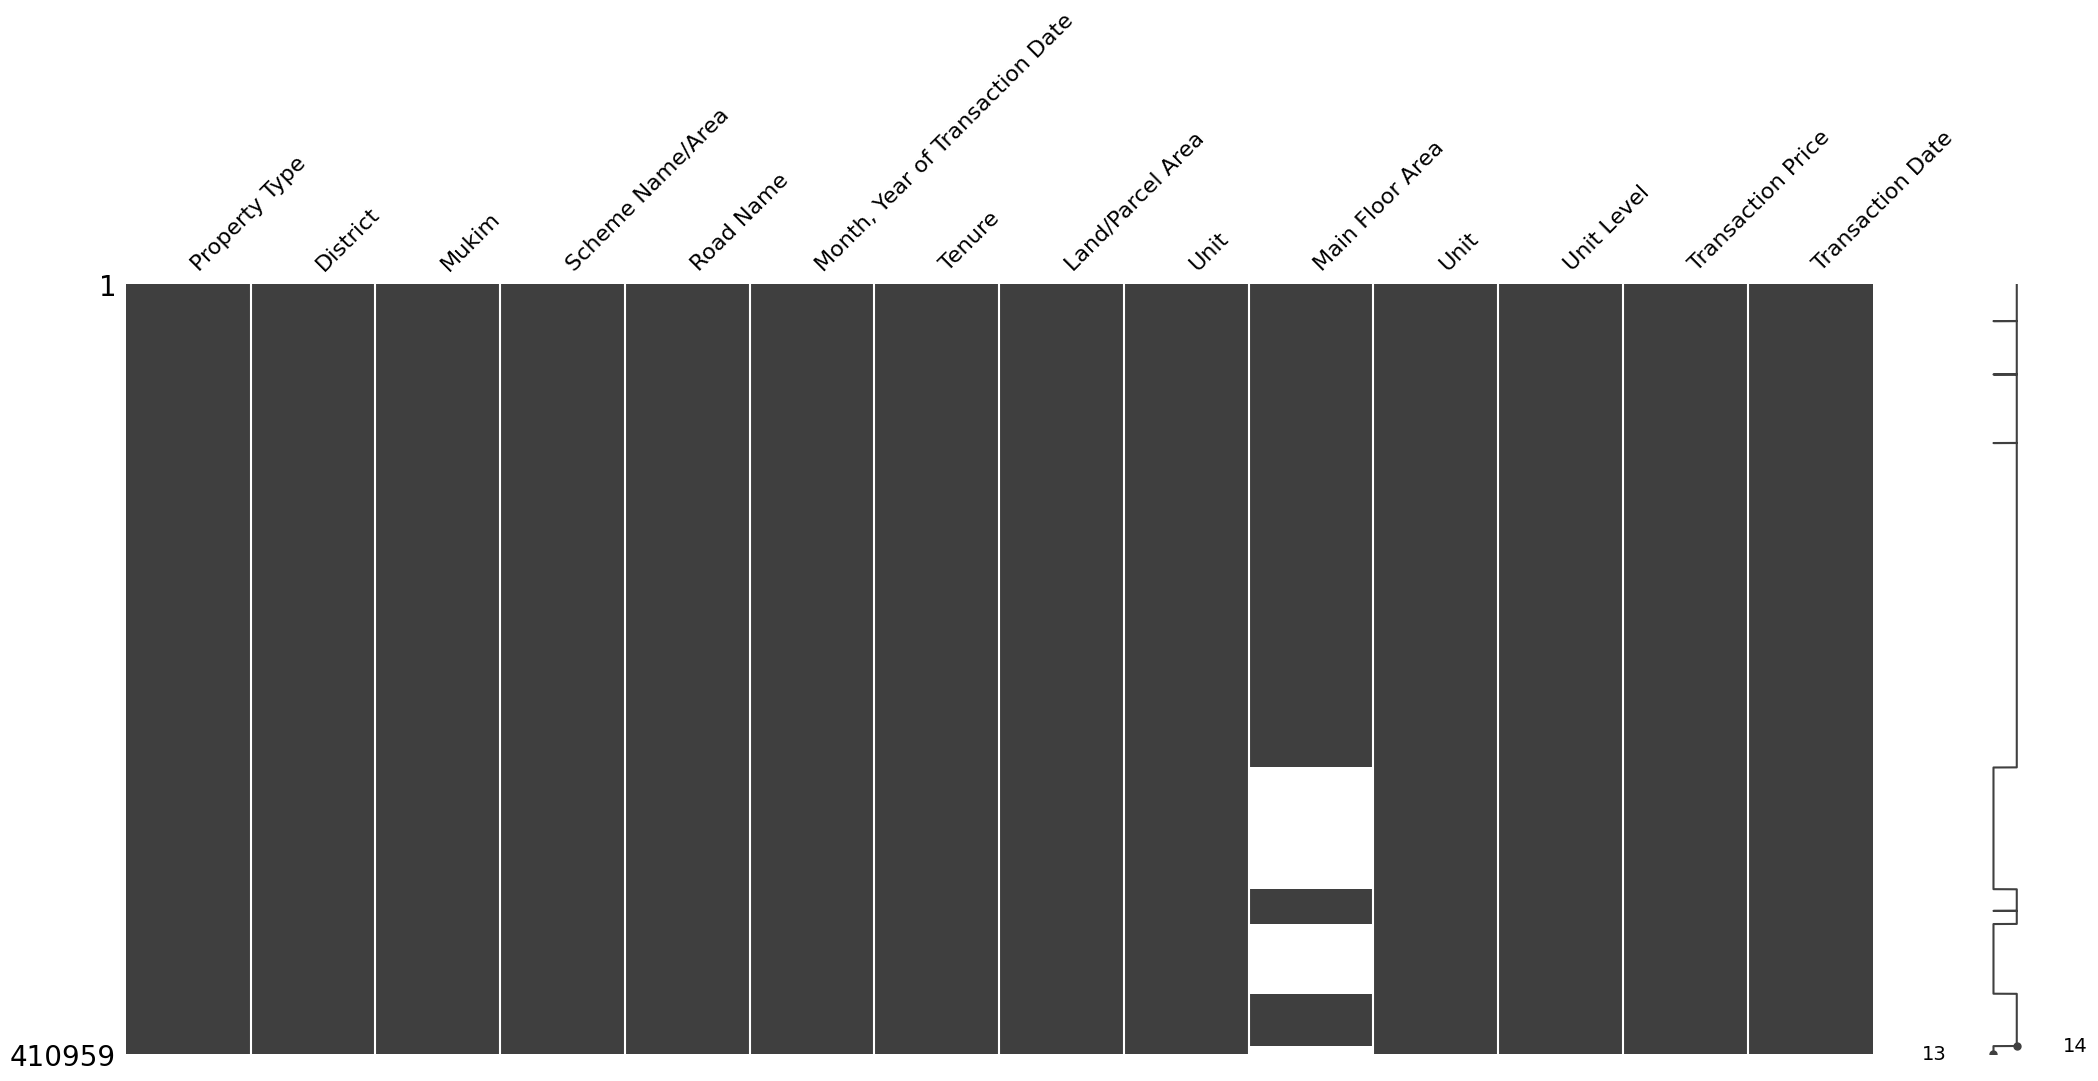

In [37]:
msno.matrix(df)  # visualizing missing numeric data with Matrix plot (missingno library)

**Handle missing values**

In [38]:
# Handle missing values in 'Main Floor Area' by filling with the median
df['Main Floor Area'] = df['Main Floor Area'].fillna(df['Main Floor Area'].median())

<Axes: >

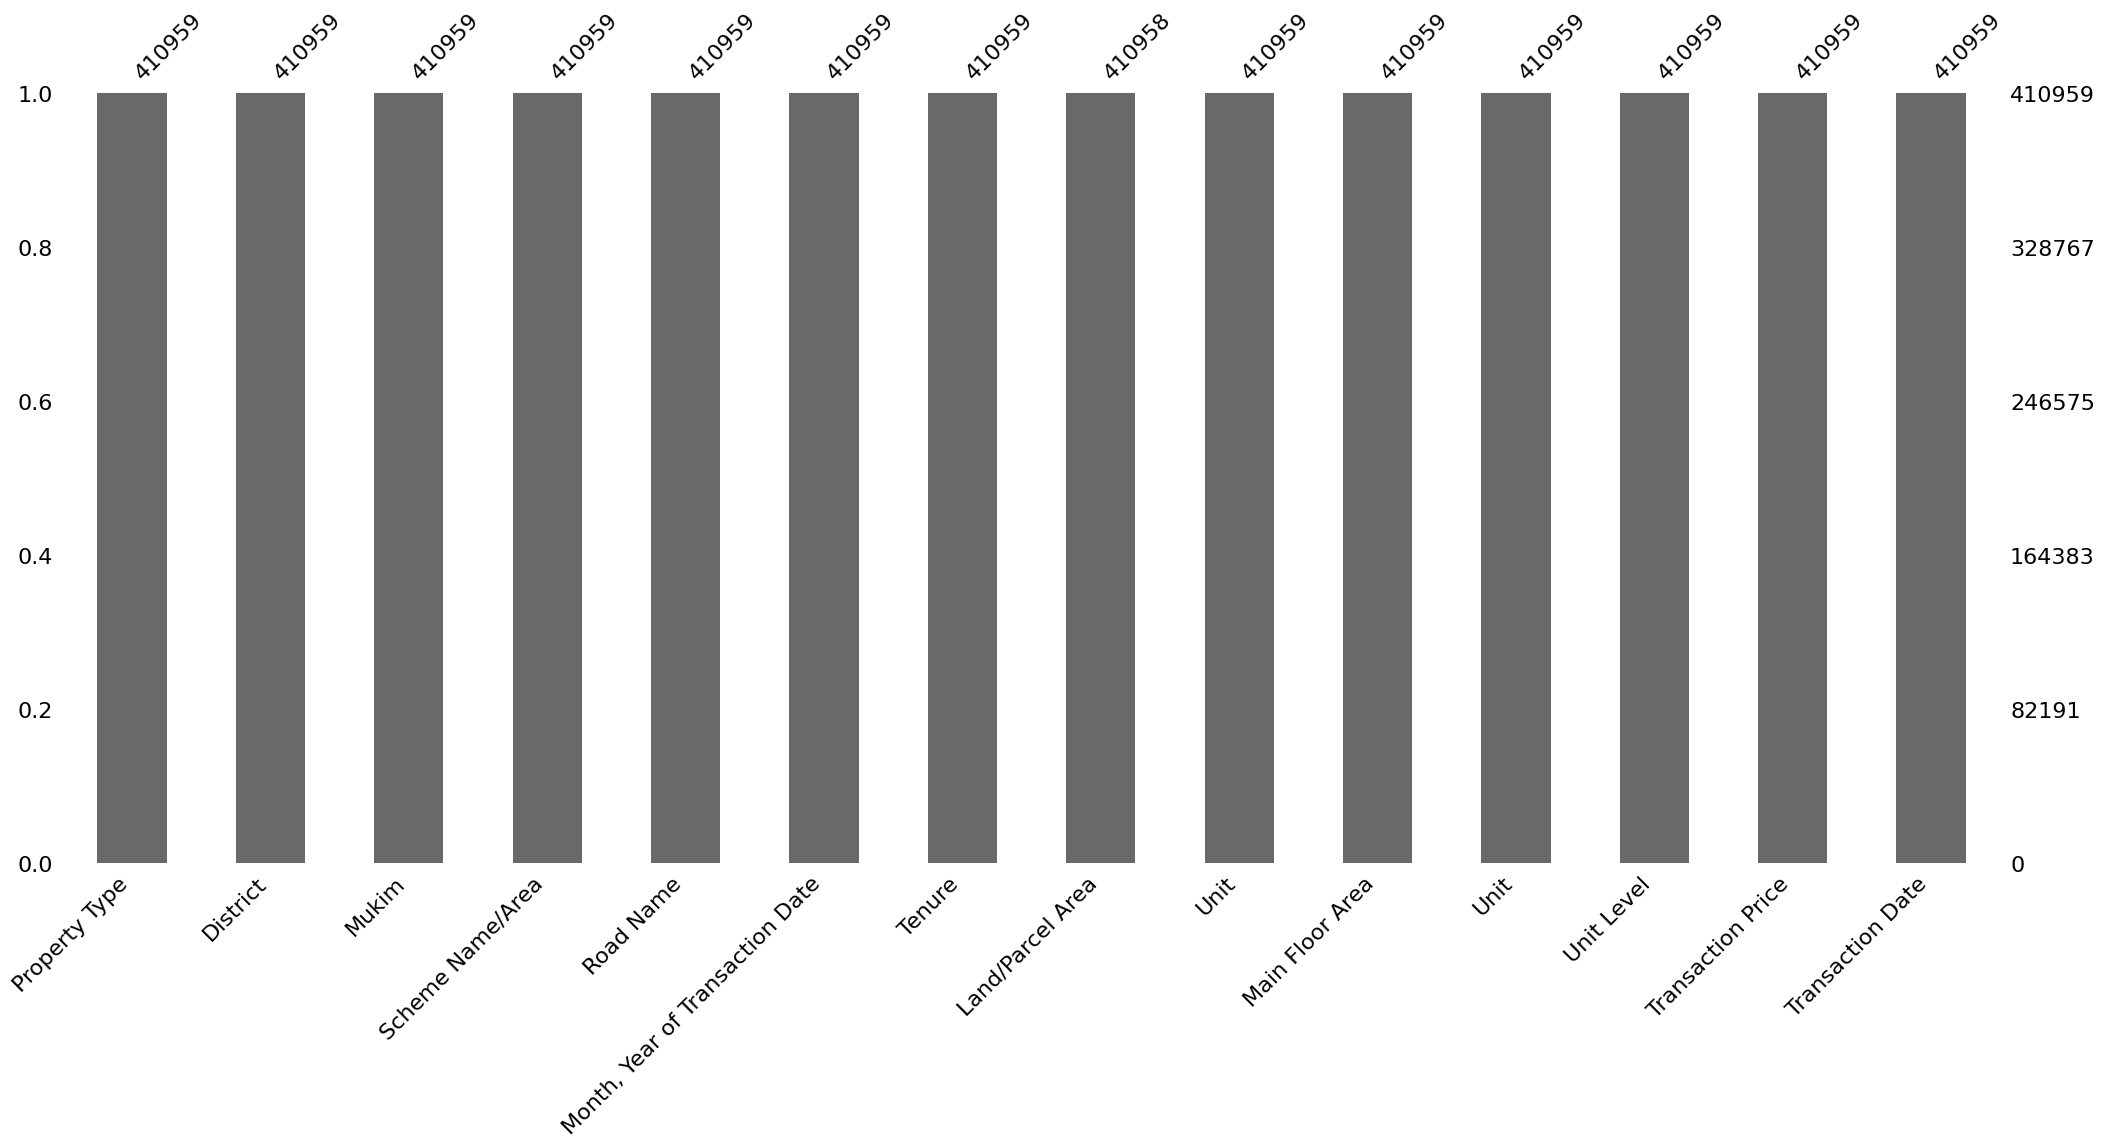

In [39]:
msno.bar(df)

<Axes: >

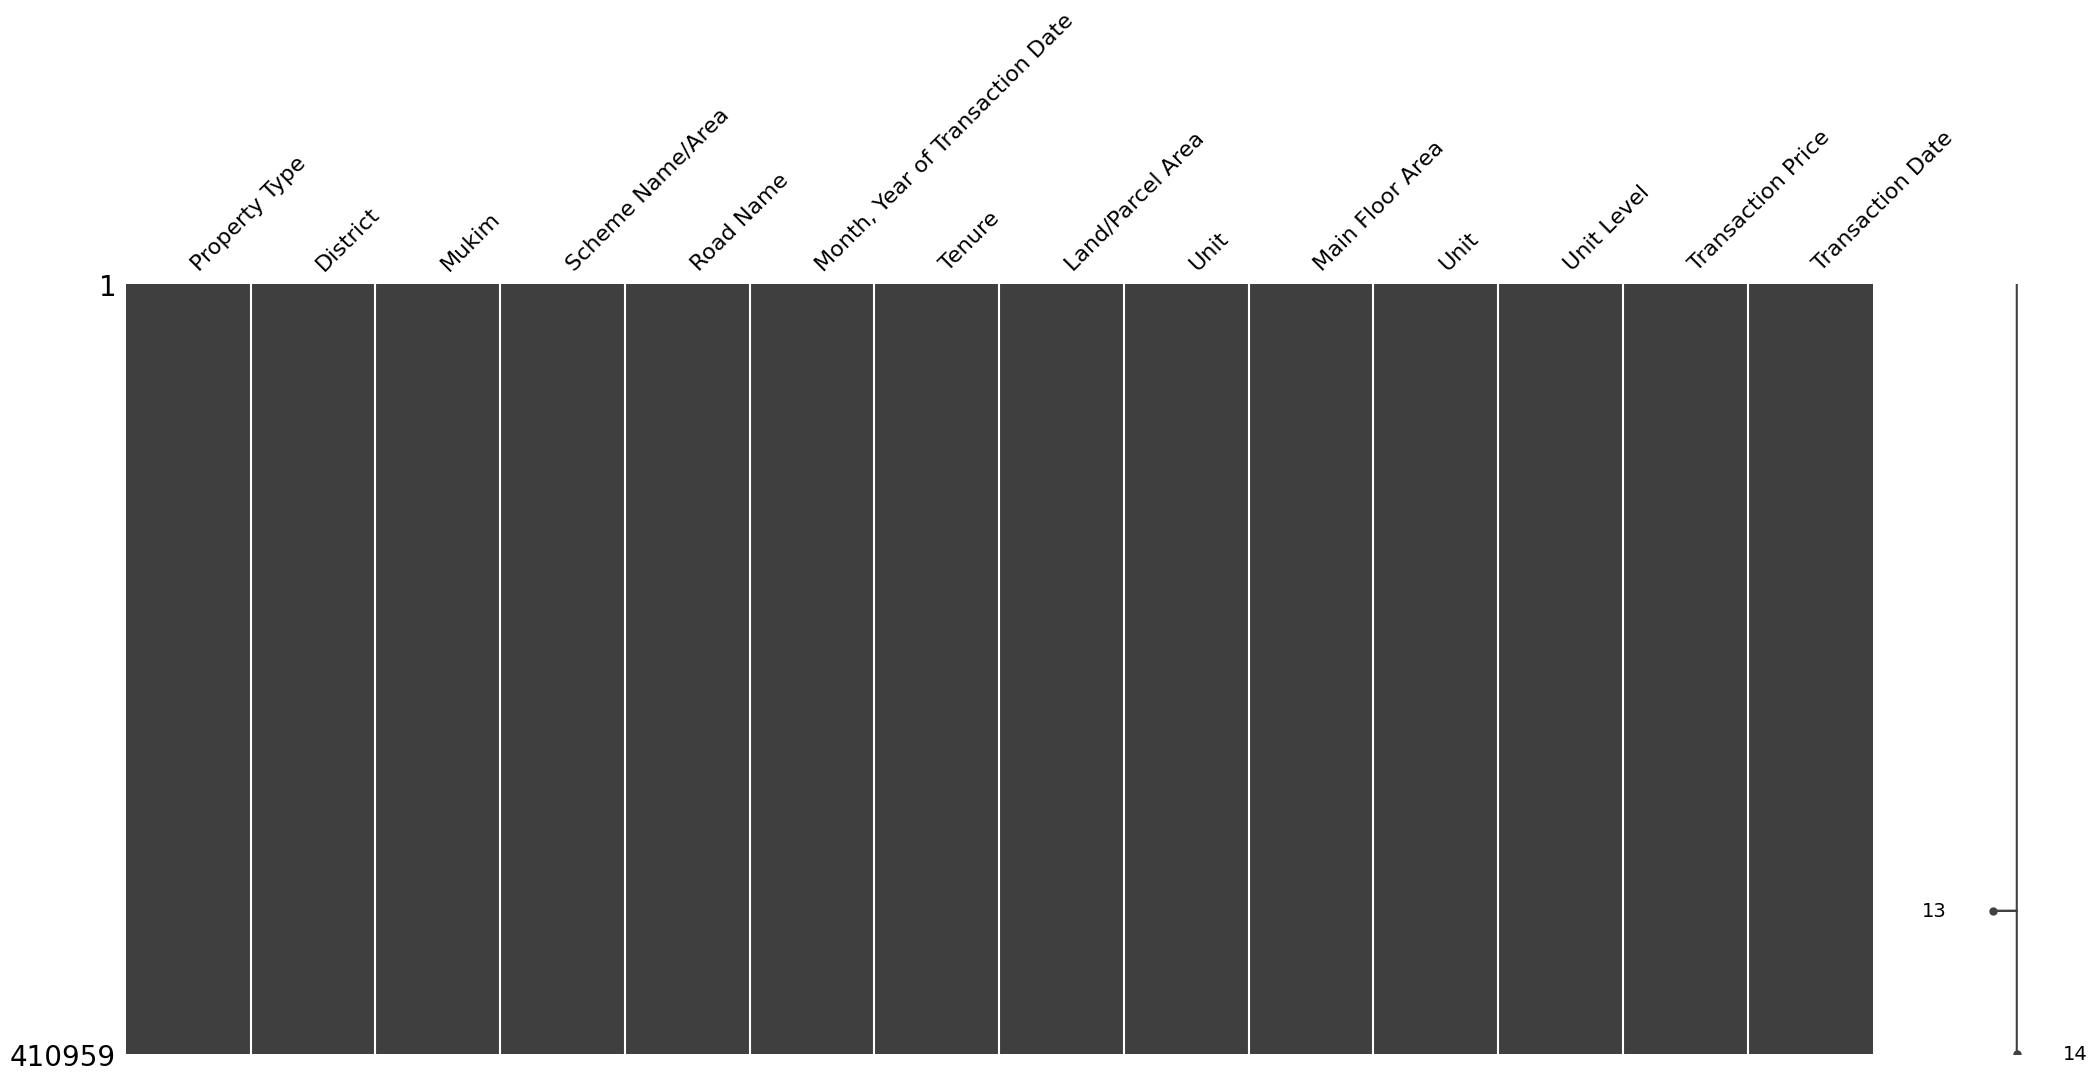

In [40]:
msno.matrix(df) 

**Johor Property Analysis**

Johor district summary with median price included:


,transactions,avg_price,median_price,avg_main_floor_area,avg_land_area,price_std,mean_median_ratio
District,,,,,,,
Johor Bahru,45701,580085.32,498000.0,131.38,232.83,430633.66,1.16
Kota Tinggi,352,284545.45,270000.0,96.34,209.80,85018.64,1.05
Kluang,39,159794.87,150000.0,103.10,150.27,32231.22,1.07
Melaka Tengah,11,277636.36,300000.0,99.82,115.21,170685.84,0.93
Kota Setar,4,180000.00,185000.0,85.75,135.75,22730.30,0.97
Batu Pahat,3,400000.00,380000.0,129.00,294.21,43588.99,1.05
Pontian,3,226666.67,250000.0,55.33,103.00,58594.65,0.91
Klang,2,875000.00,875000.0,205.50,303.82,459619.41,1.00
Kinta,1,680000.00,680000.0,108.00,339.55,NaN,1.00



Side-by-side comparison of top districts by transaction count and by median price:


,count_transactions,count_avg_price,count_median_price,count_avg_main_floor_area,count_avg_land_area,count_price_std,count_mean_median_ratio,price_transactions,price_avg_price,price_median_price,price_avg_main_floor_area,price_avg_land_area,price_price_std,price_mean_median_ratio
District,,,,,,,,,,,,,,
Johor Bahru,45701.0,580085.32,498000.0,131.38,232.83,430633.66,1.16,45701.0,580085.32,498000.0,131.38,232.83,430633.66,1.16
Kota Tinggi,352.0,284545.45,270000.0,96.34,209.80,85018.64,1.05,352.0,284545.45,270000.0,96.34,209.80,85018.64,1.05
Kluang,39.0,159794.87,150000.0,103.10,150.27,32231.22,1.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Melaka Tengah,11.0,277636.36,300000.0,99.82,115.21,170685.84,0.93,11.0,277636.36,300000.0,99.82,115.21,170685.84,0.93
Kota Setar,4.0,180000.00,185000.0,85.75,135.75,22730.30,0.97,4.0,180000.00,185000.0,85.75,135.75,22730.30,0.97
Batu Pahat,3.0,400000.00,380000.0,129.00,294.21,43588.99,1.05,3.0,400000.00,380000.0,129.00,294.21,43588.99,1.05
Pontian,3.0,226666.67,250000.0,55.33,103.00,58594.65,0.91,3.0,226666.67,250000.0,55.33,103.00,58594.65,0.91
Klang,2.0,875000.00,875000.0,205.50,303.82,459619.41,1.00,2.0,875000.00,875000.0,205.50,303.82,459619.41,1.00
Kinta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,680000.00,680000.0,108.00,339.55,NaN,1.00


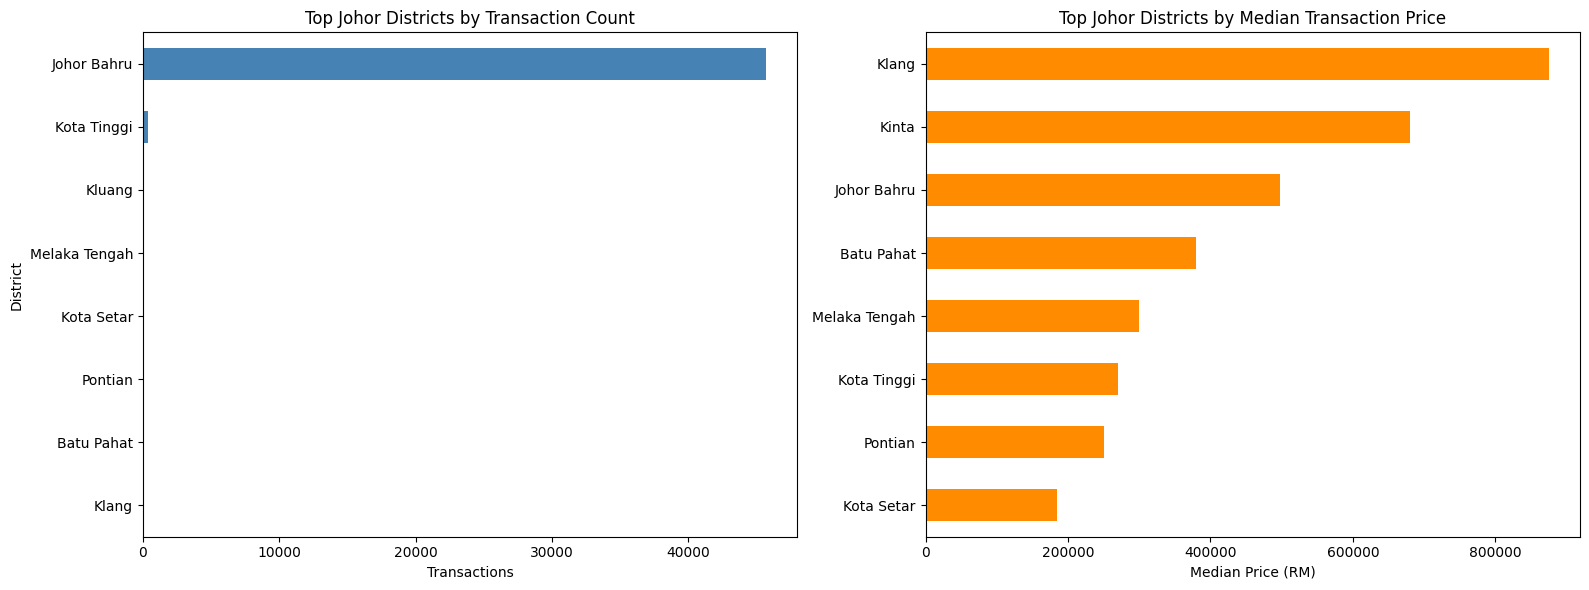

In [45]:
district_stats = (
    df_johor.groupby('District')
    .agg(
        transactions=('Transaction Price', 'count'),
        avg_price=('Transaction Price', 'mean'),
        median_price=('Transaction Price', 'median'),
        avg_main_floor_area=('Main Floor Area', 'mean'),
        avg_land_area=('Land/Parcel Area', 'mean'),
        price_std=('Transaction Price', 'std')
    )
    .round(2)
)

district_stats['mean_median_ratio'] = (district_stats['avg_price'] / district_stats['median_price']).round(2)

print("Johor district summary with median price included:")
display(district_stats.sort_values(['transactions', 'median_price'], ascending=[False, False]))

top_by_count = district_stats.sort_values('transactions', ascending=False).head(8)
top_by_median = district_stats.sort_values('median_price', ascending=False).head(8)

comparison = pd.concat(
    [top_by_count.add_prefix('count_'), top_by_median.add_prefix('price_')],
    axis=1
)

print("\nSide-by-side comparison of top districts by transaction count and by median price:")
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_by_count['transactions'].sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top Johor Districts by Transaction Count')
axes[0].set_xlabel('Transactions')
axes[0].set_ylabel('District')

top_by_median['median_price'].sort_values().plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Top Johor Districts by Median Transaction Price')
axes[1].set_xlabel('Median Price (RM)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Bivarate & Multivariate Analysis**

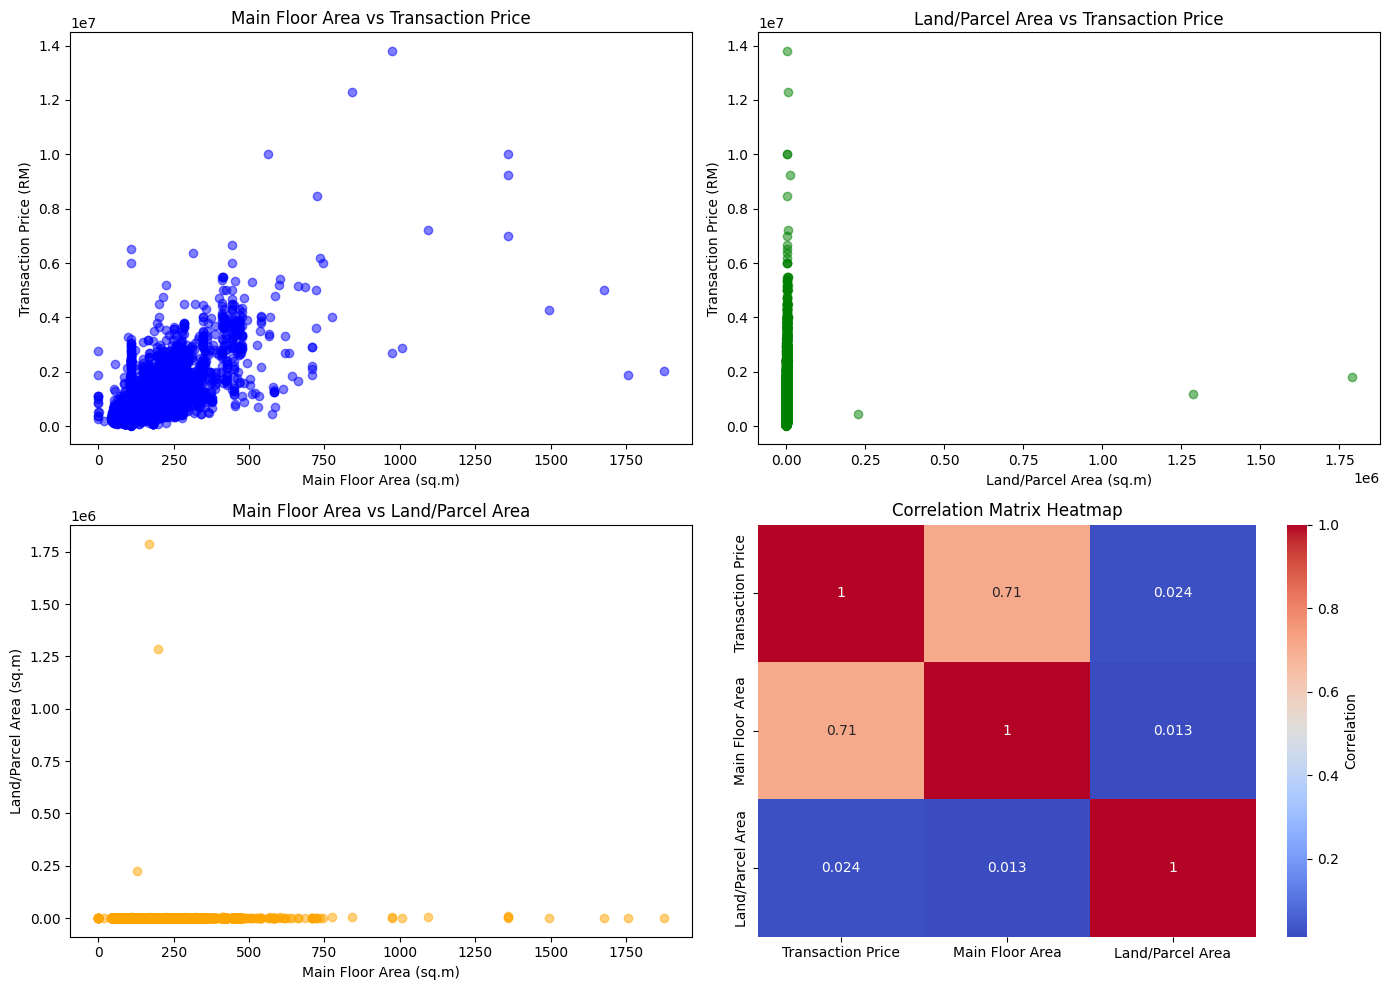

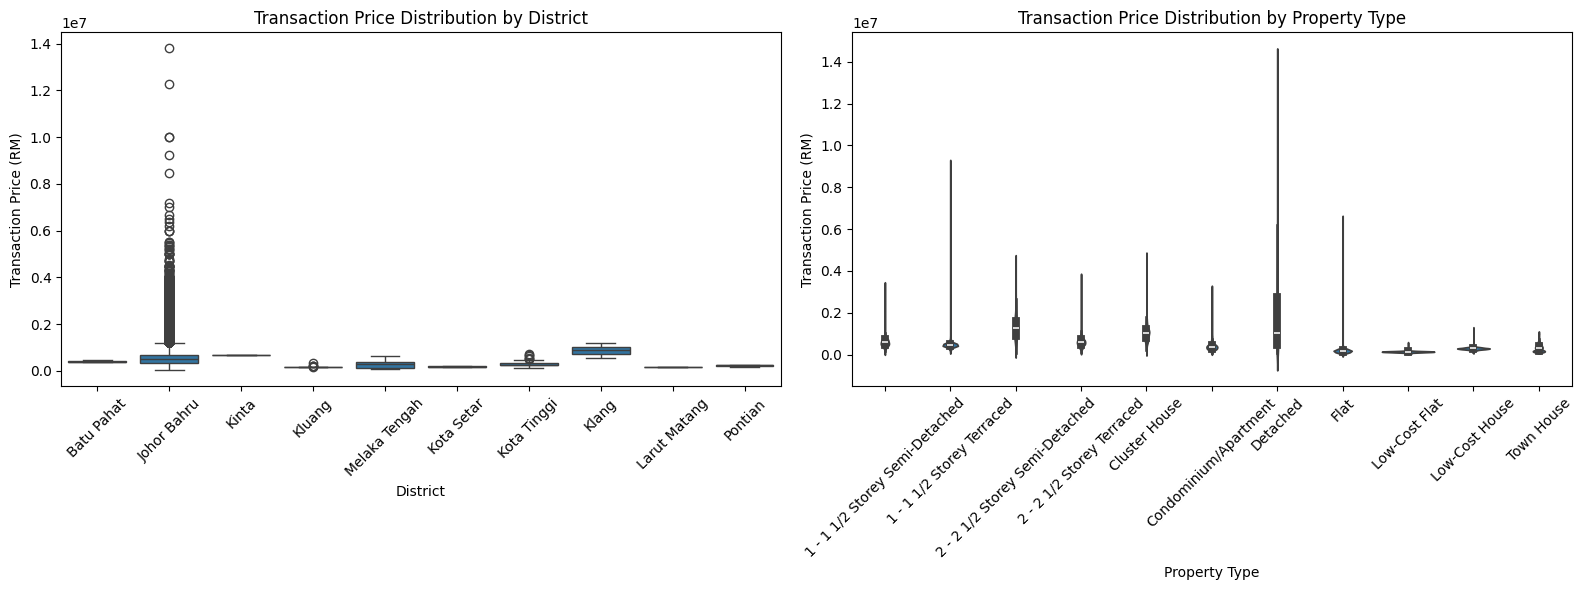


Multivariate Summary (by District and Tenure):
                        Transaction Price                  Main Floor Area  \
                                     mean    median  count            mean   
District      Tenure                                                         
Batu Pahat    Freehold          400000.00  380000.0      3          129.00   
Johor Bahru   Freehold          611603.54  520000.0  39328          134.05   
              Leasehold         385585.28  350000.0   6373          114.92   
Kinta         Freehold          680000.00  680000.0      1          108.00   
Klang         Freehold          875000.00  875000.0      2          205.50   
Kluang        Freehold          155315.79  150000.0     38          103.00   
              Leasehold         330000.00  330000.0      1          107.00   
Kota Setar    Freehold          173333.33  175000.0      3           65.00   
              Leasehold         200000.00  200000.0      1          148.00   
Kota Tinggi   Fr

In [47]:
# Bivariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot: Main Floor Area vs Transaction Price
axes[0, 0].scatter(df_johor['Main Floor Area'], df_johor['Transaction Price'], alpha=0.5, color='blue')
axes[0, 0].set_xlabel('Main Floor Area (sq.m)')
axes[0, 0].set_ylabel('Transaction Price (RM)')
axes[0, 0].set_title('Main Floor Area vs Transaction Price')

# Scatter plot: Land/Parcel Area vs Transaction Price
axes[0, 1].scatter(df_johor['Land/Parcel Area'], df_johor['Transaction Price'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Land/Parcel Area (sq.m)')
axes[0, 1].set_ylabel('Transaction Price (RM)')
axes[0, 1].set_title('Land/Parcel Area vs Transaction Price')

# Scatter plot: Main Floor Area vs Land/Parcel Area
axes[1, 0].scatter(df_johor['Main Floor Area'], df_johor['Land/Parcel Area'], alpha=0.5, color='orange')
axes[1, 0].set_xlabel('Main Floor Area (sq.m)')
axes[1, 0].set_ylabel('Land/Parcel Area (sq.m)')
axes[1, 0].set_title('Main Floor Area vs Land/Parcel Area')

# Correlation heatmap
correlation_matrix = df_johor[['Transaction Price', 'Main Floor Area', 'Land/Parcel Area']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()

# Multivariate Analysis: Transaction Price by District and Property Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Transaction Price by District
sns.boxplot(data=df_johor, x='District', y='Transaction Price', ax=axes[0])
axes[0].set_title('Transaction Price Distribution by District')
axes[0].set_xlabel('District')
axes[0].set_ylabel('Transaction Price (RM)')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot: Transaction Price by Property Type
sns.violinplot(data=df_johor, x='Property Type', y='Transaction Price', ax=axes[1])
axes[1].set_title('Transaction Price Distribution by Property Type')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Transaction Price (RM)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Multivariate summary: Average metrics by District and Tenure
multivariate_summary = df_johor.groupby(['District', 'Tenure']).agg({
    'Transaction Price': ['mean', 'median', 'count'],
    'Main Floor Area': 'mean',
    'Land/Parcel Area': 'mean'
}).round(2)

print("\nMultivariate Summary (by District and Tenure):")
print(multivariate_summary)

**Forecast/Predict future Johor property price**

Linear regression monthly price trend model MAE: 28110.95 RM
Model slope (RM per month index): 2431.09
Model intercept: 425518.36

Future Johor monthly median transaction price forecast:


,Transaction Date,Forecast Price
0,2026-01-01,573814.971751
1,2026-02-01,576246.063721
2,2026-03-01,578677.155691
3,2026-04-01,581108.247661
4,2026-05-01,583539.339631
5,2026-06-01,585970.431601
6,2026-07-01,588401.523571
7,2026-08-01,590832.615541
8,2026-09-01,593263.707511
9,2026-10-01,595694.799481


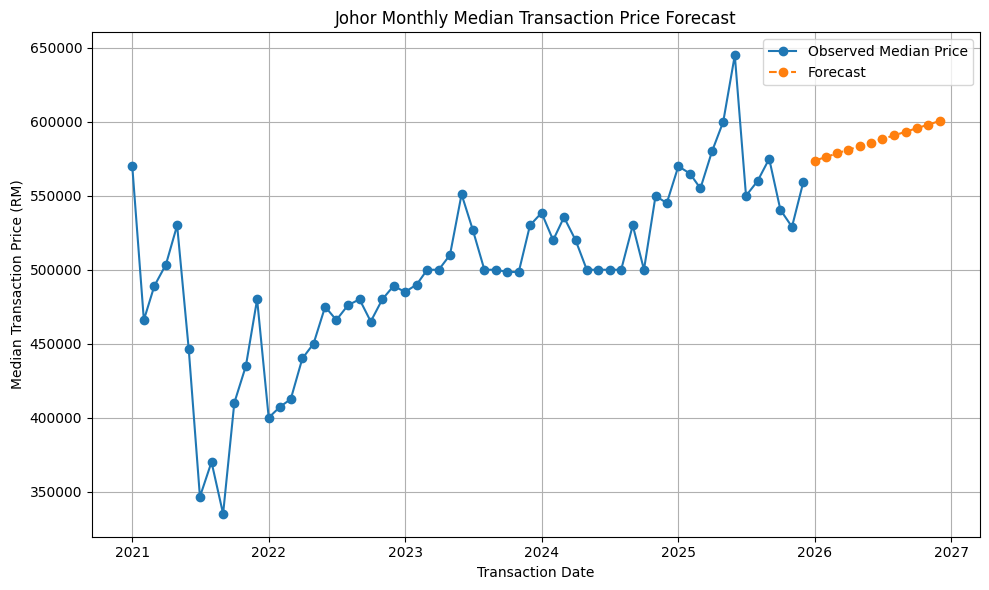

In [48]:
johor_monthly = (
    df_johor.set_index('Transaction Date')['Transaction Price']
    .resample('MS')
    .median()
    .dropna()
    .reset_index()
)

johor_monthly['month_index'] = (
    (johor_monthly['Transaction Date'].dt.year - johor_monthly['Transaction Date'].dt.year.min()) * 12
    + johor_monthly['Transaction Date'].dt.month
)

X = johor_monthly[['month_index']]
y = johor_monthly['Transaction Price']

model = LinearRegression()
model.fit(X, y)

future_periods = 12
future_dates = pd.date_range(
    start=johor_monthly['Transaction Date'].max() + pd.offsets.MonthBegin(1),
    periods=future_periods,
    freq='MS'
)
future_month_index = (
    (future_dates.year - johor_monthly['Transaction Date'].dt.year.min()) * 12
    + future_dates.month
)

forecast_df = pd.DataFrame({
    'Transaction Date': future_dates,
    'month_index': future_month_index,
})
forecast_df['Forecast Price'] = model.predict(forecast_df[['month_index']])

y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)

print(f"Linear regression monthly price trend model MAE: {mae:.2f} RM")
print(f"Model slope (RM per month index): {model.coef_[0]:.2f}")
print(f"Model intercept: {model.intercept_:.2f}\n")

print("Future Johor monthly median transaction price forecast:")
display(forecast_df[['Transaction Date', 'Forecast Price']])

plt.figure(figsize=(10, 6))
plt.plot(johor_monthly['Transaction Date'], johor_monthly['Transaction Price'], marker='o', label='Observed Median Price')
plt.plot(forecast_df['Transaction Date'], forecast_df['Forecast Price'], marker='o', linestyle='--', label='Forecast')
plt.title('Johor Monthly Median Transaction Price Forecast')
plt.xlabel('Transaction Date')
plt.ylabel('Median Transaction Price (RM)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()